# Hệ thống Lắng nghe Sinh viên

**Môn:** Ngôn ngữ lập trình Python (Đồ án cuối kỳ)

Phân tích phản hồi của sinh viên về môn học để biết mức độ hài lòng với giảng viên,
chương trình học và cơ sở vật chất, từ đó thấy được điều cần cải thiện.

**Dữ liệu:** UIT-VSFC, gồm 16.175 câu phản hồi sinh viên thật. Mỗi câu có 2 nhãn do
người gán tay: cảm xúc (tiêu cực / tích cực / trung lập) và chủ đề (giảng viên / chương
trình / cơ sở vật chất / khác). Dữ liệu chia sẵn thành 3 tập: train 11.426, dev 1.583,
test 3.166. Nguồn: Nguyen và cộng sự, UIT-VSFC, KSE 2018.

Notebook gồm 2 phần: xử lý và phân tích dữ liệu (mục 1 đến 5), rồi huấn luyện mô hình
phân loại cảm xúc và chủ đề (mục 6, 7).

Cài thư viện: `pip install pandas numpy matplotlib datasets scikit-learn`

## 0. Tải dữ liệu thật UIT-VSFC

**Bước 1: thu thập dữ liệu.** Ô dưới gọi `tai_du_lieu.py` để tải bộ dữ liệu về
`data/feedback.csv`.

Ô này tự kiểm tra: đã có file thì bỏ qua, chưa có mới tải (cần mạng). Nhờ vậy chạy lại
notebook nhiều lần cũng không tải lại và không ghi đè dữ liệu đang dùng.

File tải về có 4 cột, trong đó cột `split` cho biết mỗi câu thuộc tập train, dev hay
test. Nhóm dùng đúng cách chia này để đánh giá cho khách quan.

In [1]:
import os

DUONG_DAN = "data/feedback.csv"

if os.path.exists(DUONG_DAN):
    print("Da co", DUONG_DAN, "- bo qua buoc tai.")
else:
    try:
        from tai_du_lieu import tai
        tai(DUONG_DAN)
    except Exception as loi:
        print("Chua tai duoc du lieu (can mang):", loi)

Da co data/feedback.csv - bo qua buoc tai.


## 1. Nạp dữ liệu và tìm hiểu dữ liệu

**Bước 1: thu thập và hiểu dữ liệu.** Xác định nguồn, số mẫu, số thuộc tính, kiểu dữ
liệu và ý nghĩa của từng thuộc tính.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv("data/feedback.csv", encoding="utf-8")
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (16175, 4)


,feedback,sentiment,topic,split
0,slide giáo trình đầy đủ .,1,1,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",1,0,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",1,0,train


### 1.1. Số mẫu, số thuộc tính và ý nghĩa từng thuộc tính

In [3]:
print("Nguon du lieu : UIT-VSFC - Vietnamese Students' Feedback Corpus")
print("So mau        :", df.shape[0], "  <- bo du lieu goc co 16.175 cau")
print("So thuoc tinh :", df.shape[1])
print()
df.info()

print("""
Ý nghĩa từng thuộc tính:
  feedback  (văn bản) : câu phản hồi sinh viên viết bằng tiếng Việt
  sentiment (mã nhãn) : 0 = Tiêu cực, 1 = Tích cực, 2 = Trung lập
  topic     (mã nhãn) : 0 = Giảng viên, 1 = Chương trình,
                        2 = Cơ sở vật chất, 3 = Khác
  split     (chuỗi)   : câu này thuộc tập train / dev / test nào

Lưu ý về mã nhãn cảm xúc: dữ liệu gốc đánh 0=tiêu cực, 1=trung lập, 2=tích cực.
Đồ án đổi thành 0=tiêu cực, 1=tích cực, 2=trung lập cho dễ đọc biểu đồ.
Đây chỉ là đổi tên nhãn, không thêm/bớt dữ liệu, nên mọi chỉ số đánh giá
(accuracy, F1) đều không thay đổi.
""")

Nguon du lieu : UIT-VSFC - Vietnamese Students' Feedback Corpus
So mau        : 16175   <- bo du lieu goc co 16.175 cau
So thuoc tinh : 4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16175 entries, 0 to 16174
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   feedback   16175 non-null  object
 1   sentiment  16175 non-null  int64 
 2   topic      16175 non-null  int64 
 3   split      16175 non-null  object
dtypes: int64(2), object(2)
memory usage: 505.6+ KB

Ý nghĩa từng thuộc tính:
  feedback  — văn bản : câu phản hồi sinh viên viết bằng tiếng Việt
  sentiment — mã nhãn : 0 = Tiêu cực, 1 = Tích cực, 2 = Trung lập
  topic     — mã nhãn : 0 = Giảng viên, 1 = Chương trình,
                        2 = Cơ sở vật chất, 3 = Khác
  split     — chuỗi   : câu này thuộc tập train / dev / test nào

Lưu ý về mã nhãn cảm xúc: dữ liệu gốc đánh 0=tiêu cực, 1=trung lập, 2=tích cực.
Đồ án đổi thành 0=tiêu cực, 1=tích cực, 2=trung lậ

### 1.2. Thống kê nhanh

In [4]:
print(df[["sentiment", "topic"]].describe().round(2))
print("\nDo dai cau (so ky tu):")
print(df["feedback"].astype(str).str.len().describe().round(1))

       sentiment     topic
count   16175.00  16175.00
mean        0.58      0.43
std         0.57      0.80
min         0.00      0.00
25%         0.00      0.00
50%         1.00      0.00
75%         1.00      1.00
max         2.00      3.00

Do dai cau (so ky tu):
count    16175.0
mean        58.8
std         43.3
min          4.0
25%         31.0
50%         46.0
75%         73.0
max        718.0
Name: feedback, dtype: float64


## 2. Tiền xử lý dữ liệu

Thực hiện lần lượt: kiểm tra kiểu dữ liệu → giá trị thiếu → dữ liệu không hợp lệ →
trùng lặp → làm sạch văn bản → gán nhãn chữ → nhiễu & ngoại lai → lưu file sạch.

### 2.1. Kiểm tra và chuyển đổi kiểu dữ liệu

**Bước 2.** Cột `feedback` để dạng chuỗi. Còn `sentiment` và `topic` tuy là số nhưng
thực ra là mã nhãn (0, 1, 2...), không phải số để tính trung bình. Nên ở mục 2.6 nhóm
đổi chúng sang kiểu `category` cho đúng bản chất, vẫn giữ cột số để đưa vào mô hình.

In [5]:
print("Kieu du lieu ban dau:")
print(df.dtypes)

df["feedback"] = df["feedback"].astype(str)

# giá trị lạ (chữ) sẽ thành NaN để bước sau bắt được
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df["topic"] = pd.to_numeric(df["topic"], errors="coerce")

print("\nKieu du lieu sau khi chuyen:")
print(df.dtypes)

Kieu du lieu ban dau:
feedback     object
sentiment     int64
topic         int64
split        object
dtype: object

Kieu du lieu sau khi chuyen:
feedback     object
sentiment     int64
topic         int64
split        object
dtype: object


### 2.2. Kiểm tra giá trị thiếu và giá trị trùng lặp

**Bước 3 và bước 5.** Xem có ô nào bị thiếu (NaN, rỗng) và có bản ghi nào bị lặp không.

In [6]:
print("Giá trị thiếu mỗi cột:")
print(df.isnull().sum())
print("\nSố dòng trùng lặp:", df.duplicated().sum())

Giá trị thiếu mỗi cột:
feedback     0
sentiment    0
topic        0
split        0
dtype: int64

Số dòng trùng lặp: 0


### 2.3. Xử lý giá trị thiếu và bản ghi trùng lặp

Ở đây chọn cách xóa dòng thay vì điền trung bình / trung vị / mode, vì:
- `feedback` là văn bản, không có "trung bình của một câu" để điền.
- `sentiment`, `topic` là nhãn, điền mode sẽ tạo ra nhãn giả làm sai lệch kết quả.

In [7]:
truoc = len(df)

df = df.dropna(subset=["feedback", "sentiment", "topic"])
df = df[df["feedback"].str.strip() != ""]
df = df.drop_duplicates()

print(f"Truoc: {truoc} dong  ->  Sau: {len(df)} dong  (bo {truoc - len(df)} dong)")

Truoc: 16175 dong  ->  Sau: 16175 dong  (bo 0 dong)


### 2.4. Xử lý dữ liệu không hợp lệ

**Bước 4.** Dữ liệu có thể không thiếu nhưng vẫn sai logic. Với bộ dữ liệu này, ba lỗi
logic có thể xảy ra:

1. Nhãn nằm ngoài tập cho phép (ví dụ `sentiment = 5` khi chỉ có 0, 1, 2).
2. Câu phản hồi quá ngắn (dưới 2 từ như `"ok"`, `"..."`), không mang thông tin để phân tích.
3. Câu không chứa chữ cái nào (chỉ có số hoặc ký tự lạ).

In [8]:
truoc = len(df)

# (a) nhãn phải nằm trong tập cho phép
sai_cx = ~df["sentiment"].isin([0, 1, 2])
sai_cd = ~df["topic"].isin([0, 1, 2, 3])
print("Dong co nhan cam xuc khong hop le :", sai_cx.sum())
print("Dong co nhan chu de khong hop le  :", sai_cd.sum())
df = df[~sai_cx & ~sai_cd]

# (b) câu phải có ít nhất 2 từ
qua_ngan = df["feedback"].str.split().str.len() < 2
print("Dong co duoi 2 tu                 :", qua_ngan.sum())
df = df[~qua_ngan]

# (c) câu phải chứa ít nhất một chữ cái
khong_co_chu = ~df["feedback"].str.contains(r"[a-zA-Zà-ỹ]", regex=True)
print("Dong khong chua chu cai nao       :", khong_co_chu.sum())
df = df[~khong_co_chu]

df["sentiment"] = df["sentiment"].astype(int)
df["topic"] = df["topic"].astype(int)

print(f"\nTruoc: {truoc} dong  ->  Sau: {len(df)} dong")

Dong co nhan cam xuc khong hop le : 0
Dong co nhan chu de khong hop le  : 0


Dong co duoi 2 tu                 : 0
Dong khong chua chu cai nao       : 0

Truoc: 16175 dong  ->  Sau: 16175 dong


### 2.5. Làm sạch văn bản (chuẩn hóa)

**Bước 7: chuẩn hóa dữ liệu.** Với văn bản, chuẩn hóa nghĩa là đưa về chữ thường, bỏ
ký tự đặc biệt (giữ nguyên chữ có dấu tiếng Việt), gộp khoảng trắng thừa. Nhờ vậy
`"Thầy"`, `"thầy"`, `"thầy!"` được coi là cùng một từ.

In [9]:
def lam_sach(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễ"
                  r"ìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["feedback_sach"] = df["feedback"].apply(lam_sach)
df[["feedback", "feedback_sach"]].head()

,feedback,feedback_sach
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",nhiệt tình giảng dạy gần gũi với sinh viên
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",thầy giảng bài hay có nhiều bài tập ví dụ ngay...


### 2.6. Gán nhãn dạng chữ và mã hóa kiểu phân loại

**Bước 8 và bước 11.** Dữ liệu đã có nhãn sẵn (do nhóm tác giả UIT-VSFC gán thủ công)
nên không phải gán lại. Chỉ cần đổi mã số sang nhãn chữ cho dễ đọc khi vẽ biểu đồ, và
khai báo kiểu `category` cho đúng bản chất dữ liệu phân loại.

In [10]:
ten_cx = {0: "Tiêu cực", 1: "Tích cực", 2: "Trung lập"}
ten_cd = {0: "Giảng viên", 1: "Chương trình", 2: "Cơ sở vật chất", 3: "Khác"}

df["ten_cam_xuc"] = df["sentiment"].map(ten_cx).astype("category")
df["ten_chu_de"] = df["topic"].map(ten_cd).astype("category")

print("Kieu du lieu cua 2 cot nhan moi:")
print(df[["ten_cam_xuc", "ten_chu_de"]].dtypes)
print("\nSo cau moi lop chu de:")
print(df["ten_chu_de"].value_counts())
df[["feedback_sach", "ten_cam_xuc", "ten_chu_de"]].head()

Kieu du lieu cua 2 cot nhan moi:
ten_cam_xuc    category
ten_chu_de     category
dtype: object

So cau moi lop chu de:
ten_chu_de
Giảng viên        11607
Chương trình       3040
Khác                816
Cơ sở vật chất      712
Name: count, dtype: int64


,feedback_sach,ten_cam_xuc,ten_chu_de
0,slide giáo trình đầy đủ,Tích cực,Chương trình
1,nhiệt tình giảng dạy gần gũi với sinh viên,Tích cực,Giảng viên
2,đi học đầy đủ full điểm chuyên cần,Tiêu cực,Chương trình
3,chưa áp dụng công nghệ thông tin và các thiết ...,Tiêu cực,Giảng viên
4,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,Tích cực,Giảng viên


### 2.7. Phát hiện nhiễu và ngoại lai

**Bước 6.** Dữ liệu văn bản không có "giá trị đo sai" kiểu nhịp tim bằng 0, nên nhóm
kiểm tra ngoại lai trên độ dài phản hồi (số từ), là đại lượng số duy nhất có ý nghĩa.
Dùng đủ các cách theo yêu cầu: thống kê mô tả, boxplot, IQR và z-score.

In [11]:
df["so_tu"] = df["feedback_sach"].str.split().str.len()

print("Thong ke do dai phan hoi (so tu):")
print(df["so_tu"].describe().round(2))

# --- Cách 1: IQR ---
q1, q3 = df["so_tu"].quantile([0.25, 0.75])
iqr = q3 - q1
nguong_duoi, nguong_tren = q1 - 1.5 * iqr, q3 + 1.5 * iqr
ngoai_lai_iqr = (df["so_tu"] < nguong_duoi) | (df["so_tu"] > nguong_tren)
print(f"\n[IQR]     Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}"
      f"  -> khoang binh thuong [{nguong_duoi:.1f}, {nguong_tren:.1f}] tu")
print(f"          So cau bi coi la ngoai lai: {ngoai_lai_iqr.sum()}"
      f" ({ngoai_lai_iqr.mean()*100:.1f}%)")

# --- Cách 2: z-score ---
z = (df["so_tu"] - df["so_tu"].mean()) / df["so_tu"].std()
ngoai_lai_z = z.abs() > 3
print(f"\n[z-score] So cau co |z| > 3: {ngoai_lai_z.sum()}"
      f" ({ngoai_lai_z.mean()*100:.1f}%)")

print("\n3 cau dai bat thuong nhat:")
for cau in df.nlargest(3, "so_tu")["feedback"]:
    print("  -", cau[:110], "...")

Thong ke do dai phan hoi (so tu):
count    16175.00
mean        12.60
std          9.57
min          1.00
25%          6.00
50%         10.00
75%         16.00
max        150.00
Name: so_tu, dtype: float64

[IQR]     Q1=6  Q3=16  IQR=10  -> khoang binh thuong [-9.0, 31.0] tu
          So cau bi coi la ngoai lai: 771 (4.8%)

[z-score] So cau co |z| > 3: 286 (1.8%)

3 cau dai bat thuong nhat:
  - giảng viên rất nhiệt tình thậm chí dạy lố giờ , dư buổi nhưng vẫn không đảm bảo đủ số bài của chương trình học ...
  - thầy cho nghỉ quá nhiểu mà không sắp xếp giáo viên dạy thay , vì vậy dẫn tới việc học bù liên tiếp vào những n ...
  - thầy nên hướng dẫn cụ thể về vấn đề đồ án , bọn em lúc làm đồ án không biết làm cái gì và đang làm cái gì , đế ...


#### Boxplot độ dài phản hồi

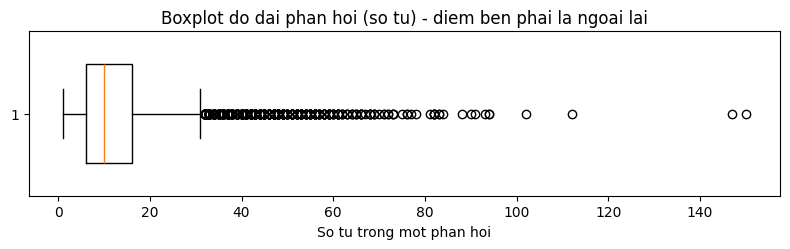

In [12]:
plt.figure(figsize=(8, 2.6))
plt.boxplot(df["so_tu"], vert=False, widths=0.6)
plt.title("Boxplot do dai phan hoi (so tu) - diem ben phai la ngoai lai")
plt.xlabel("So tu trong mot phan hoi")
plt.tight_layout(); plt.show()

### 2.8. Quyết định xử lý ngoại lai

Phát hiện được rồi, câu hỏi là **có nên xóa không?** Không xóa theo cảm tính, mà
kiểm tra xem nhóm ngoại lai có làm lệch dữ liệu hay không: so sánh tỷ lệ nhãn của
nhóm ngoại lai với toàn bộ dữ liệu.

In [13]:
print("Ty le cam xuc - TOAN BO du lieu (%):")
print((df["ten_cam_xuc"].value_counts(normalize=True) * 100).round(1))

print("\nTy le cam xuc - NHOM NGOAI LAI theo IQR (%):")
print((df[ngoai_lai_iqr]["ten_cam_xuc"].value_counts(normalize=True) * 100).round(1))

print(f"\nSo dong se mat neu xoa het ngoai lai IQR: {ngoai_lai_iqr.sum()}"
      f" ({ngoai_lai_iqr.mean()*100:.1f}% du lieu)")

# Nếu muốn xóa ngoại lai, bỏ dấu # ở dòng dưới:
# df = df[~ngoai_lai_iqr]

df = df.reset_index(drop=True)
print("\nSo dong dung cho phan tich:", len(df))

Ty le cam xuc - TOAN BO du lieu (%):
ten_cam_xuc
Tích cực     49.7
Tiêu cực     46.0
Trung lập     4.3
Name: proportion, dtype: float64

Ty le cam xuc - NHOM NGOAI LAI theo IQR (%):
ten_cam_xuc
Tiêu cực     83.0
Tích cực     15.7
Trung lập     1.3
Name: proportion, dtype: float64

So dong se mat neu xoa het ngoai lai IQR: 771 (4.8% du lieu)

So dong dung cho phan tich: 16175


**Kết luận của nhóm: giữ lại các câu dài bất thường.** Lý do dựa trên chính số liệu
ở trên:

- Nhóm ngoại lai lệch hẳn về tiêu cực (khoảng 82%) so với toàn bộ dữ liệu (khoảng 46%).
  Điều này hợp lý, vì sinh viên viết dài khi có chuyện muốn phàn nàn kỹ. Nếu xóa 5,9%
  "ngoại lai" này, ta sẽ xóa đúng phần phản hồi tiêu cực chi tiết nhất, làm kết quả
  phân tích trông tích cực hơn thực tế. Đó là sai lệch nghiêm trọng với một đồ án có
  mục đích tìm điều cần cải thiện.
- Câu dài không phải lỗi đo. IQR và z-score được thiết kế cho đại lượng đo lường (tuổi,
  nhịp tim, giá tiền); áp vào độ dài văn bản thì chỉ nên dùng để hiểu dữ liệu, không
  phải để xóa dữ liệu.
- Nhiễu thật sự (câu 1 từ, câu không có chữ cái) đã bị loại ở mục 2.4.

Code xóa vẫn để sẵn dạng ghi chú ở trên để chứng minh nhóm làm được cả hai hướng.

Đây là một phát hiện nên nói khi bảo vệ: độ dài phản hồi tương quan với cảm xúc tiêu
cực. Mục 3.4 sẽ xác nhận lại bằng số trung bình từng nhóm.

### 2.9. Lưu dữ liệu đã xử lý

**Bước 13.** Lưu ra ba định dạng, mỗi định dạng một mục đích. Phần này áp dụng đọc/ghi
JSON và XML của Chương 4:

- `data/feedback_clean.csv`: toàn bộ dữ liệu sạch, để bước phân tích và huấn luyện dùng
  luôn mà không phải xử lý lại từ đầu (Chương 8).
- `data/thong_ke.json`: bảng thống kê tóm tắt dạng JSON, để chương trình khác đọc được.
  Ghi bằng `json.dump` rồi đọc lại bằng `json.load` để chứng minh file ghi ra đúng.
- `data/thong_ke.xml`: cùng bảng thống kê đó nhưng dạng XML, ghi bằng
  `xml.etree.ElementTree`.

Ngoài ra nhóm tách dữ liệu thành 4 file CSV theo chủ đề trong `data/theo_chu_de/`, dùng
lại ở mục 8.3 để đo tốc độ đọc bằng nhiều luồng. File gốc `feedback.csv` giữ nguyên,
không ghi đè.

In [14]:
import json
import os
import xml.etree.ElementTree as ET

os.makedirs("data", exist_ok=True)

# --- 1) dữ liệu sạch -> CSV ---
df.to_csv("data/feedback_clean.csv", index=False, encoding="utf-8")
print("Da luu", len(df), "dong vao data/feedback_clean.csv")

# --- 2) bảng thống kê -> JSON ---
thong_ke = {
    "so_phan_hoi": len(df),
    "cam_xuc": df["ten_cam_xuc"].value_counts().to_dict(),
    "chu_de": df["ten_chu_de"].value_counts().to_dict(),
    "do_dai_trung_binh": round(df["so_tu"].mean(), 2),
}
with open("data/thong_ke.json", "w", encoding="utf-8") as f:
    json.dump(thong_ke, f, ensure_ascii=False, indent=2)
print("Da ghi data/thong_ke.json")

# đọc lại để kiểm tra file ghi ra đúng
with open("data/thong_ke.json", encoding="utf-8") as f:
    doc_lai = json.load(f)
print("Doc lai JSON -> so_phan_hoi =", doc_lai["so_phan_hoi"],
      "| khop voi du lieu dang co:", doc_lai["so_phan_hoi"] == len(df))

# --- 3) cùng bảng thống kê -> XML ---
goc = ET.Element("thong_ke", {"nguon": "UIT-VSFC"})
ET.SubElement(goc, "so_phan_hoi").text = str(thong_ke["so_phan_hoi"])
ET.SubElement(goc, "do_dai_trung_binh").text = str(thong_ke["do_dai_trung_binh"])

for ten_nhom, khoa in [("cam_xuc", "cam_xuc"), ("chu_de", "chu_de")]:
    nhom = ET.SubElement(goc, ten_nhom)
    for nhan, so_luong in thong_ke[khoa].items():
        ET.SubElement(nhom, "muc", {"ten": nhan}).text = str(so_luong)

cay = ET.ElementTree(goc)
ET.indent(cay, space="  ")          # cho file xuong dong dep, de doc
cay.write("data/thong_ke.xml", encoding="utf-8", xml_declaration=True)
print("Da ghi data/thong_ke.xml")

# đọc lại XML để kiểm tra
goc_doc = ET.parse("data/thong_ke.xml").getroot()
print("Doc lai XML  -> so_phan_hoi =", goc_doc.findtext("so_phan_hoi"))
print("               cac lop cam xuc:",
      [m.get("ten") for m in goc_doc.find("cam_xuc")])

# --- 4) tách 4 file CSV theo chủ đề (dùng lại ở mục 8.3) ---
os.makedirs("data/theo_chu_de", exist_ok=True)
DUONG_DAN_CHU_DE = []
for ten_chu_de, nhom_df in df.groupby("ten_chu_de", observed=True):
    ten_file = f"data/theo_chu_de/{ten_chu_de}.csv"
    nhom_df.to_csv(ten_file, index=False, encoding="utf-8")
    DUONG_DAN_CHU_DE.append(ten_file)
    print(f"  {ten_file}: {len(nhom_df)} dong")

print("\nNoi dung file JSON vua ghi:")
print(json.dumps(thong_ke, ensure_ascii=False, indent=2))

Da luu 16175 dong vao data/feedback_clean.csv
Da ghi data/thong_ke.json
Doc lai JSON -> so_phan_hoi = 16175 | khop voi du lieu dang co: True
Da ghi data/thong_ke.xml
Doc lai XML  -> so_phan_hoi = 16175
               cac lop cam xuc: ['Tích cực', 'Tiêu cực', 'Trung lập']
  data/theo_chu_de/Chương trình.csv: 3040 dong
  data/theo_chu_de/Cơ sở vật chất.csv: 712 dong


  data/theo_chu_de/Giảng viên.csv: 11607 dong
  data/theo_chu_de/Khác.csv: 816 dong

Noi dung file JSON vua ghi:
{
  "so_phan_hoi": 16175,
  "cam_xuc": {
    "Tích cực": 8038,
    "Tiêu cực": 7439,
    "Trung lập": 698
  },
  "chu_de": {
    "Giảng viên": 11607,
    "Chương trình": 3040,
    "Khác": 816,
    "Cơ sở vật chất": 712
  },
  "do_dai_trung_binh": 12.6
}


## 3. Phân tích dữ liệu

### 3.1. Phân bố cảm xúc

In [15]:
pb_cx = df["ten_cam_xuc"].value_counts()
print("Số lượng:\n", pb_cx)
print("\nTỷ lệ %:\n", (df["ten_cam_xuc"].value_counts(normalize=True)*100).round(1))

Số lượng:
 ten_cam_xuc
Tích cực     8038
Tiêu cực     7439
Trung lập     698
Name: count, dtype: int64

Tỷ lệ %:
 ten_cam_xuc
Tích cực     49.7
Tiêu cực     46.0
Trung lập     4.3
Name: proportion, dtype: float64


### 3.2. Phân bố chủ đề

In [16]:
print(df["ten_chu_de"].value_counts())

ten_chu_de
Giảng viên        11607
Chương trình       3040
Khác                816
Cơ sở vật chất      712
Name: count, dtype: int64


### 3.3. Phân tích chéo: cảm xúc theo chủ đề

Cho biết chủ đề nào bị chê nhiều, chủ đề nào được khen nhiều.

In [17]:
bang_cheo = pd.crosstab(df["ten_chu_de"], df["ten_cam_xuc"])
print("Số lượng:\n", bang_cheo)
print("\nTỷ lệ % theo chủ đề:\n",
      (pd.crosstab(df["ten_chu_de"], df["ten_cam_xuc"], normalize="index")*100).round(1))

Số lượng:
 ten_cam_xuc     Tiêu cực  Trung lập  Tích cực
ten_chu_de                                   
Chương trình        2328        162       550
Cơ sở vật chất       681         13        18
Giảng viên          4105        292      7210
Khác                 325        231       260

Tỷ lệ % theo chủ đề:
 ten_cam_xuc     Tiêu cực  Trung lập  Tích cực
ten_chu_de                                   
Chương trình        76.6        5.3      18.1
Cơ sở vật chất      95.6        1.8       2.5
Giảng viên          35.4        2.5      62.1
Khác                39.8       28.3      31.9


### 3.4. Độ dài phản hồi theo cảm xúc

In [18]:
df["so_tu"] = df["feedback_sach"].str.split().str.len()
print(df.groupby("ten_cam_xuc", observed=True)["so_tu"].mean().round(1))

ten_cam_xuc
Tiêu cực     15.3
Trung lập     8.6
Tích cực     10.4
Name: so_tu, dtype: float64


### 3.5. Từ khóa phổ biến

Đếm từ xuất hiện nhiều nhất trong phản hồi tích cực và tiêu cực, sau khi bỏ stopword
(từ xuất hiện ở mọi loại phản hồi nên không phân biệt được gì, ví dụ "của", "và",
"sinh", "viên", "học").

Đếm thêm cụm 2 từ vì tiếng Việt phần lớn là từ ghép: đếm từ đơn thì ra "nhiệt" và
"tình" rời rạc, đếm cụm 2 từ mới ra "nhiệt tình", đọc mới hiểu sinh viên đang khen hay
chê điều gì.

Danh sách stopword này dùng chung với `app.py` để notebook và web ra cùng kết quả.

In [19]:
# dùng chung danh sách stopword với app.py
STOPWORDS = {
    "của", "và", "là", "có", "cho", "được", "các", "những", "một", "để", "với",
    "khi", "này", "đã", "rất", "em", "thầy", "cô", "còn", "nên", "cần", "quá",
    "trong", "về", "ở", "ra", "lại", "như", "mà", "thì",
    # từ xuất hiện ở mọi loại phản hồi, không mang nghĩa cảm xúc
    "sinh", "viên", "giảng", "học", "dạy", "bài", "thực", "môn", "lớp",
    "tiết", "buổi", "hay", "hơn", "theo", "cũng", "vẫn", "đều",
    "không", "nhiều", "ít", "tôi", "mình", "nhưng", "vào", "làm", "giáo",
}


def top_tu(df_con, n=10):
    """Dem tu don xuat hien nhieu nhat, da bo stopword."""
    tu = " ".join(df_con["feedback_sach"]).split()
    tu = [t for t in tu if t not in STOPWORDS and len(t) > 1]
    return Counter(tu).most_common(n)


def top_cum_2_tu(df_con, n=10):
    """Dem cum 2 tu lien tiep xuat hien nhieu nhat."""
    dem = Counter()
    for cau in df_con["feedback_sach"]:
        tu = cau.split()
        for i in range(len(tu) - 1):
            dem[tu[i] + " " + tu[i + 1]] += 1
    return dem.most_common(n)


for ma, ten in [(1, "TICH CUC"), (0, "TIEU CUC")]:
    nhom = df[df["sentiment"] == ma]
    print(f"--- Phan hoi {ten} ---")
    print("  Tu don :", top_tu(nhom, 8))
    print("  Cum 2 tu:", top_cum_2_tu(nhom, 6))
    print()

print("--- Cum 2 tu trong phan hoi ve CO SO VAT CHAT ---")
print(top_cum_2_tu(df[df["topic"] == 2], 8))

--- Phan hoi TICH CUC ---
  Tu don : [('tình', 3017), ('nhiệt', 2623), ('dễ', 1805), ('hiểu', 1632), ('tâm', 1332), ('tận', 1330), ('vui', 950), ('kiến', 814)]


  Cum 2 tu: [('nhiệt tình', 2495), ('sinh viên', 1857), ('dễ hiểu', 1358), ('giảng viên', 1260), ('giảng dạy', 946), ('tận tâm', 771)]



--- Phan hoi TIEU CUC ---
  Tu don : [('tập', 1150), ('hành', 1060), ('khó', 900), ('hiểu', 768), ('chưa', 755), ('thức', 602), ('lý', 596), ('trình', 550)]


  Cum 2 tu:

 [('sinh viên', 1844), ('thực hành', 1035), ('giảng viên', 944), ('bài tập', 872), ('môn học', 688), ('cho sinh', 468)]

--- Cum 2 tu trong phan hoi ve CO SO VAT CHAT ---
[('thực hành', 229), ('thiết bị', 169), ('phòng học', 142), ('máy chiếu', 118), ('sinh viên', 98), ('phòng thực', 95), ('chất lượng', 81), ('phòng máy', 79)]


## 4. Trực quan hóa

### 4.1. Biểu đồ cột: phân bố cảm xúc

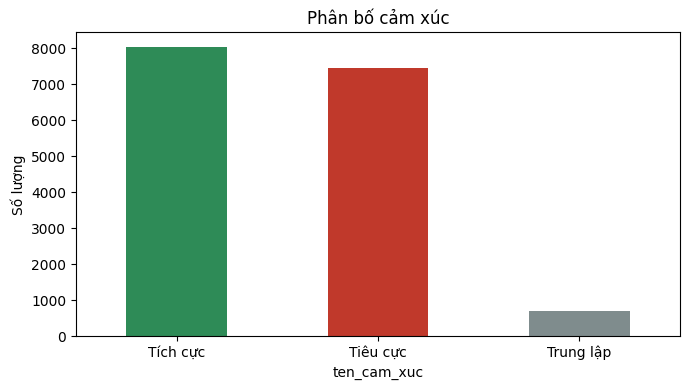

In [20]:
mau = {"Tiêu cực":"#c0392b","Tích cực":"#2e8b57","Trung lập":"#7f8c8d"}
plt.figure(figsize=(7,4))
pb_cx.plot(kind="bar", color=[mau[x] for x in pb_cx.index])
plt.title("Phân bố cảm xúc"); plt.ylabel("Số lượng"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### 4.2. Biểu đồ tròn: tỷ lệ cảm xúc

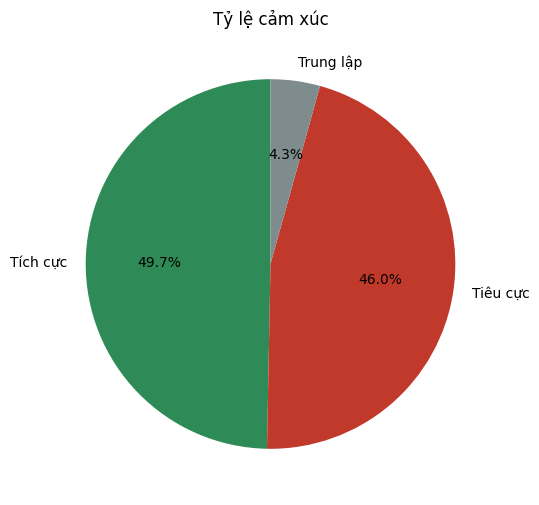

In [21]:
plt.figure(figsize=(6,6))
plt.pie(pb_cx, labels=pb_cx.index, autopct="%1.1f%%",
        colors=[mau[x] for x in pb_cx.index], startangle=90)
plt.title("Tỷ lệ cảm xúc"); plt.show()

### 4.3. Biểu đồ cột nhóm: cảm xúc theo chủ đề

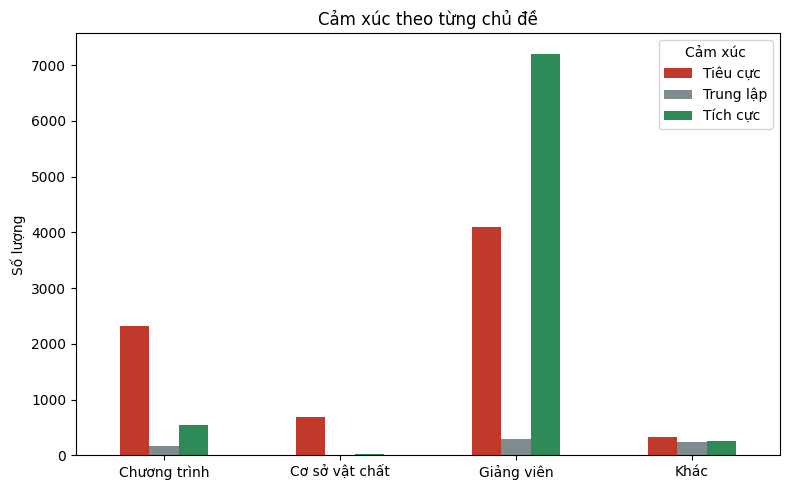

In [22]:
bang_cheo.plot(kind="bar", figsize=(8,5),
               color=[mau.get(c,"#888") for c in bang_cheo.columns])
plt.title("Cảm xúc theo từng chủ đề"); plt.ylabel("Số lượng")
plt.xlabel(""); plt.xticks(rotation=0); plt.legend(title="Cảm xúc")
plt.tight_layout(); plt.show()

### 4.4. Biểu đồ cột: phân bố chủ đề

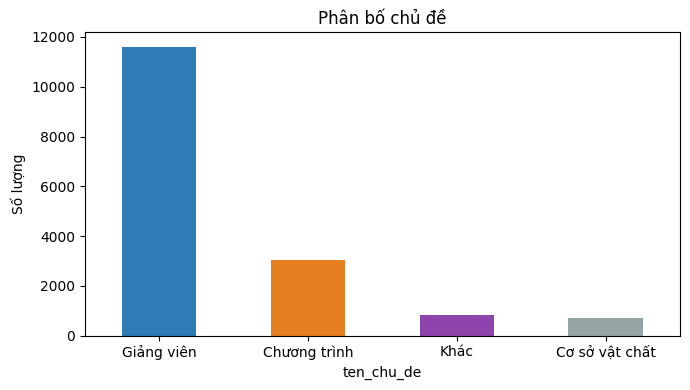

In [23]:
pb_cd = df["ten_chu_de"].value_counts()
plt.figure(figsize=(7,4))
pb_cd.plot(kind="bar", color=["#2e7bb5", "#e67e22", "#8e44ad", "#95a5a6"])
plt.title("Phân bố chủ đề"); plt.ylabel("Số lượng"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 5. Nhận xét và kết luận

Các con số dưới đây lấy từ chính kết quả đã chạy ở mục 3 và 4 (16.175 phản hồi).

### 5.1. Bức tranh tổng thể

Phản hồi chia gần đều hai phía: tích cực 8.038 câu (49,7%) và tiêu cực 7.439 câu
(46,0%), trung lập chỉ 698 câu (4,3%). Nghĩa là gần một nửa phản hồi là lời chê, không
thể kết luận "sinh viên hài lòng" rồi bỏ qua.

Lớp trung lập ít như vậy là hợp lý với thực tế: sinh viên chỉ ngồi viết góp ý khi thấy
rất tốt hoặc rất tệ, ít ai viết một câu trung tính.

### 5.2. Chủ đề nào bị chê, chủ đề nào được khen

| Chủ đề | Số phản hồi | % tiêu cực | % tích cực |
|---|---|---|---|
| Cơ sở vật chất | 712 (4,4%) | 95,6% | 2,5% |
| Chương trình học | 3.040 (18,8%) | 76,6% | 18,1% |
| Khác | 816 (5,0%) | 39,8% | 31,9% |
| Giảng viên | 11.607 (71,8%) | 35,4% | 62,1% |

Ba điều đọc ra được từ bảng này:

1. Cơ sở vật chất là điểm yếu nặng nhất: 95,6% phản hồi về nó là tiêu cực, chỉ 2,5%
   tích cực, gần như không ai khen. Chủ đề này chỉ chiếm 4,4% tổng phản hồi nên nếu chỉ
   nhìn số lượng thì dễ bỏ qua: ít người nhắc tới, nhưng ai nhắc cũng chê. Cụm từ hay
   gặp: thiết bị (169 lần), phòng học (142), máy chiếu (118), phòng máy (79).
2. Chương trình học: 76,6% tiêu cực. Cụm từ nổi nhất trong nhóm tiêu cực là thực hành
   (1.035 lần), rồi bài tập (872), thời gian (438), lý thuyết (413). Sinh viên muốn
   nhiều giờ thực hành hơn, ít lý thuyết hơn.
3. Giảng viên là điểm mạnh của trường: 62,1% tích cực, và cũng là chủ đề được nhắc
   nhiều nhất (71,8% phản hồi). Cụm từ được khen nhiều nhất: nhiệt tình (2.495 lần),
   dễ hiểu (1.358), tận tâm (771).

Nhóm "Khác" có tỷ lệ trung lập cao bất thường (28,3% so với 4,3% của toàn bộ dữ liệu),
hợp lý vì câu không nói rõ chủ đề thì thường cũng không nói rõ thái độ.

### 5.3. Người không hài lòng viết dài hơn

Độ dài trung bình: tiêu cực 15,3 từ, tích cực 10,4 từ, trung lập 8,6 từ. Câu chê dài
hơn câu khen khoảng 47%: khen thì "thầy dạy hay", còn chê thì kể rõ chê cái gì. Đây
cũng là lý do ở mục 2.8 nhóm không xóa các câu dài bất thường, vì xóa chúng là xóa đúng
phần phản hồi tiêu cực chi tiết nhất.

### 5.4. Kiến nghị cho nhà trường

Xếp theo thứ tự ưu tiên mà số liệu chỉ ra:

1. Cơ sở vật chất, ưu tiên cao nhất. Tỷ lệ chê 95,6% là mức không còn gì để bàn. Việc
   cụ thể: rà soát máy chiếu, phòng máy, thiết bị phòng thực hành.
2. Tăng thời lượng thực hành trong chương trình. Đây là nội dung được nhắc nhiều nhất
   trong nhóm phản hồi tiêu cực.
3. Giữ và nhân rộng cách dạy của các giảng viên được khen. "Nhiệt tình", "dễ hiểu",
   "tận tâm" là ba từ sinh viên dùng nhiều nhất khi khen.

### 5.5. Ý nghĩa ứng dụng

Thay vì đọc tay 16.175 phản hồi, hệ thống tổng hợp được bức tranh trên trong vài giây,
và chỉ ra đúng chỗ cần sửa kèm bằng chứng bằng số. Với mỗi học kỳ mới, chỉ cần thay
file dữ liệu là có ngay báo cáo tương ứng.

## 6. Huấn luyện mô hình phân loại cảm xúc

Mục này thực hiện 3 bước còn lại của quy trình xử lý dữ liệu:

- Bước 12: chia dữ liệu thành train / dev / test (mục 6.1).
- Bước 10: xử lý đặc trưng bằng TF-IDF (mục 6.2).
- Bước 9: xử lý dữ liệu mất cân bằng (mục 6.3).

Mô hình dùng là `LogisticRegression` đa lớp của scikit-learn.

### 6.1. Chia dữ liệu train / dev / test (bước 12)

Bộ dữ liệu đã chia sẵn 16.175 câu thành train 11.426, dev 1.583, test 3.166 (ghi ở cột
`split`). Nhóm đọc thẳng cột này thay vì tự chia ngẫu nhiên, để việc đánh giá được
khách quan:

| Tập | Số câu | Dùng để làm gì |
|---|---|---|
| train | 11.426 | huấn luyện mô hình |
| dev (validation) | 1.583 | chọn cách xử lý mất cân bằng ở mục 6.3 |
| test | 3.166 | chỉ dùng một lần cuối để báo kết quả |

Nếu gộp cả 3 tập rồi tự chia ngẫu nhiên thì kết quả không còn khách quan, vì mô hình có
thể vô tình học trúng những câu dùng để chấm.

In [24]:
print("So cau moi tap (theo cot 'split' co san trong du lieu):")
for ten in ["train", "dev", "test"]:
    print(f"  {ten:5}: {(df['split'] == ten).sum()}")

df_train = df[df["split"] == "train"]
df_dev = df[df["split"] == "dev"]
df_test = df[df["split"] == "test"]

print("\nTy le nhan cam xuc tung tap (%) - da chia san, khong can stratify:")
print(pd.DataFrame({
    "train": df_train["ten_cam_xuc"].value_counts(normalize=True).mul(100).round(1),
    "dev": df_dev["ten_cam_xuc"].value_counts(normalize=True).mul(100).round(1),
    "test": df_test["ten_cam_xuc"].value_counts(normalize=True).mul(100).round(1),
}))

So cau moi tap (theo cot 'split' co san trong du lieu):
  train: 11426
  dev  : 1583
  test : 3166

Ty le nhan cam xuc tung tap (%) - da chia san, khong can stratify:
             train   dev  test
ten_cam_xuc                   
Tích cực      49.4  50.9  50.2
Tiêu cực      46.6  44.5  44.5
Trung lập      4.0   4.6   5.3


### 6.2. Xử lý đặc trưng bằng TF-IDF (bước 10)

Mô hình không hiểu chữ, phải đổi câu thành vector số. TF-IDF cho mỗi từ một điểm: từ
xuất hiện nhiều trong một câu nhưng ít trong toàn bộ dữ liệu thì điểm cao (từ đặc
trưng), từ xuất hiện ở mọi câu thì điểm thấp (từ vô nghĩa).

Tạo đặc trưng mới: `ngram_range=(1, 2)` lấy thêm cụm 2 từ, để `"không hay"` khác
`"hay"`. Điều này quan trọng với tiếng Việt vì từ phủ định làm đảo nghĩa cả câu.

Loại bỏ đặc trưng không cần thiết: `min_df=2` bỏ những cụm chỉ xuất hiện đúng một lần
trong hơn 11.000 câu train. Phần lớn là lỗi chính tả, không giúp mô hình học được gì
mà chỉ làm tăng chiều dữ liệu.

Một điểm kỹ thuật quan trọng: TF-IDF chỉ được `fit` trên tập train, rồi `transform` cho
dev và test. Nếu `fit` trên toàn bộ dữ liệu thì mô hình đã "nhìn thấy" từ vựng của tập
test trước khi thi, gọi là rò rỉ dữ liệu (data leakage), làm kết quả đẹp giả tạo.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

b1 = TfidfVectorizer(ngram_range=(1, 1), min_df=1).fit(df_train["feedback_sach"])
b2 = TfidfVectorizer(ngram_range=(1, 2), min_df=1).fit(df_train["feedback_sach"])
print("Chi tu don (1-gram)      :", len(b1.vocabulary_), "dac trung")
print("Them cum 2 tu (1-2 gram) :", len(b2.vocabulary_), "dac trung  <- tao dac trung moi")

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)

# chỉ fit trên train -> không rò rỉ dữ liệu test
X_train = vec.fit_transform(df_train["feedback_sach"])
X_val = vec.transform(df_dev["feedback_sach"])
X_test = vec.transform(df_test["feedback_sach"])

y_train = df_train["sentiment"]
y_val = df_dev["sentiment"]
y_test = df_test["sentiment"]

da_bo = len(b2.vocabulary_) - X_train.shape[1]
print("Sau khi bo cum chi xuat hien 1 lan (min_df=2):", X_train.shape[1], "dac trung")
print(f"   -> loai bo {da_bo} dac trung nhieu ({da_bo/len(b2.vocabulary_)*100:.1f}%)")
print("\nKich thuoc ma tran:")
print("  X_train:", X_train.shape)
print("  X_val  :", X_val.shape)
print("  X_test :", X_test.shape)
print("\n10 dac trung dau tien:", list(vec.get_feature_names_out()[:10]))

Chi tu don (1-gram)      : 2459 dac trung
Them cum 2 tu (1-2 gram) : 33843 dac trung  <- tao dac trung moi


Sau khi bo cum chi xuat hien 1 lan (min_df=2): 13154 dac trung
   -> loai bo 20689 dac trung nhieu (61.1%)

Kich thuoc ma tran:
  X_train: (11426, 13154)
  X_val  : (1583, 13154)
  X_test : (3166, 13154)

10 dac trung dau tien: ['10', '10 người', '10 điểm', '100', '12', '13h30', '15', '15 20', '15 phút', '1dot5']


### 6.3. Xử lý dữ liệu mất cân bằng (bước 9)

Dữ liệu lệch nhãn nặng: lớp "Trung lập" chỉ chiếm khoảng 4%. Hậu quả là mô hình có thể
bỏ qua hẳn lớp này mà vẫn đạt accuracy cao. Đây là lý do không được chỉ nhìn accuracy
với dữ liệu mất cân bằng, phải xem thêm F1 macro (trung bình điểm của cả 3 lớp, lớp ít
mẫu cũng tính bằng lớp nhiều mẫu).

Nhóm thử 4 cách rồi chọn cách tốt nhất trên tập dev:

1. Không xử lý gì, làm mốc so sánh.
2. Class weighting: không đổi dữ liệu, chỉ báo mô hình đoán sai lớp ít thì bị phạt nặng hơn.
3. Random undersampling: giảm số mẫu của lớp nhiều xuống bằng lớp ít.
4. Random oversampling: tăng lớp ít bằng cách lấy mẫu lặp lại cho bằng lớp nhiều.

Cách 3 và 4 tự cài bằng numpy nên không cần thư viện ngoài. Bốn cách được gom vào một
`dict` rồi chạy bằng một vòng lặp, thay vì viết bốn khối lệnh giống nhau.

In [26]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("So mau moi lop trong tap train:")
print(y_train.value_counts().rename(index=ten_cx))


def lay_mau_lai(y_tr, kieu, seed=42):
    """kieu='under': giam ve lop it nhat. kieu='over': tang ve lop nhieu nhat."""
    vi_tri = pd.Series(range(len(y_tr)))     # danh so cac dong: 0, 1, 2, ...
    dem = y_tr.value_counts()
    n = dem.min() if kieu == "under" else dem.max()

    cac_nhom = []
    for lop in sorted(y_tr.unique()):
        vi_tri_cua_lop = vi_tri[y_tr.values == lop]
        # replace=True: cho lấy lại một dòng nhiều lần
        cac_nhom.append(vi_tri_cua_lop.sample(n=n, replace=len(vi_tri_cua_lop) < n,
                                              random_state=seed))

    gop = pd.concat(cac_nhom)
    return gop.sample(frac=1, random_state=seed).tolist()   # frac=1 = tron ngau nhien


cach = {"1. Khong xu ly": (X_train, y_train, None),
        "2. Class weighting": (X_train, y_train, "balanced")}
for kieu, ten in [("under", "3. Random undersampling"), ("over", "4. Random oversampling")]:
    vt = lay_mau_lai(y_train, kieu)
    cach[ten] = (X_train[vt], y_train.iloc[vt], None)

ket_qua, mo_hinh_da_thu = [], {}
for ten, (Xtr, ytr, trong_so) in cach.items():
    mh_i = LogisticRegression(max_iter=1000, class_weight=trong_so).fit(Xtr, ytr)
    dd = mh_i.predict(X_val)
    mo_hinh_da_thu[ten] = mh_i
    ket_qua.append({"Cach xu ly": ten, "So mau train": Xtr.shape[0],
                    "Accuracy (dev)": round(accuracy_score(y_val, dd) * 100, 2),
                    "F1 weighted (dev)": round(f1_score(y_val, dd, average="weighted") * 100, 2),
                    "F1 macro (dev)": round(f1_score(y_val, dd, average="macro") * 100, 2)})

bang_kq = pd.DataFrame(ket_qua)
print("\nSo sanh 4 cach xu ly mat can bang (do tren tap DEV):")
print(bang_kq.to_string(index=False))

tot_nhat = bang_kq.loc[bang_kq["F1 macro (dev)"].idxmax(), "Cach xu ly"]
print(f"\n=> Cach cho F1 macro cao nhat: {tot_nhat}")

So mau moi lop trong tap train:
sentiment
Tích cực     5643
Tiêu cực     5325
Trung lập     458
Name: count, dtype: int64



So sanh 4 cach xu ly mat can bang (do tren tap DEV):
             Cach xu ly  So mau train  Accuracy (dev)  F1 weighted (dev)  F1 macro (dev)
         1. Khong xu ly         11426           90.90              89.43           68.35
     2. Class weighting         11426           88.06              88.82           75.00
3. Random undersampling          1374           77.20              81.17           65.15
 4. Random oversampling         16929           88.44              89.14           75.91

=> Cach cho F1 macro cao nhat: 4. Random oversampling


#### Biểu đồ so sánh: Accuracy, F1 weighted và F1 macro

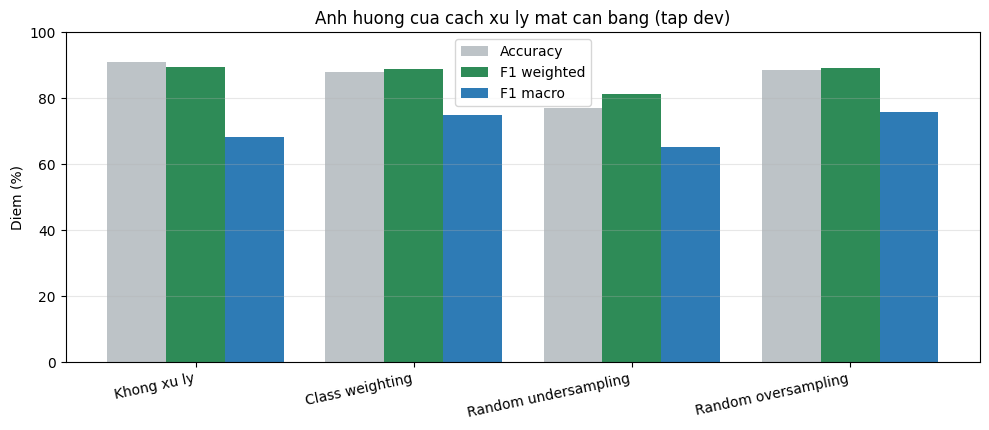

In [27]:
truc = np.arange(len(bang_kq))
rong = 0.27
plt.figure(figsize=(10, 4.4))
plt.bar(truc - rong, bang_kq["Accuracy (dev)"], rong, label="Accuracy", color="#bdc3c7")
plt.bar(truc, bang_kq["F1 weighted (dev)"], rong, label="F1 weighted", color="#2e8b57")
plt.bar(truc + rong, bang_kq["F1 macro (dev)"], rong, label="F1 macro", color="#2e7bb5")
plt.xticks(truc, [t.split(". ")[1] for t in bang_kq["Cach xu ly"]],
           rotation=12, ha="right")
plt.ylabel("Diem (%)"); plt.ylim(0, 100)
plt.title("Anh huong cua cach xu ly mat can bang (tap dev)")
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Cách đọc kết quả này khi bảo vệ:**

- Cách 1 (không xử lý) thường có accuracy và F1 weighted cao nhất, nhưng F1 macro thấp
  nhất: mô hình gần như bỏ hẳn lớp "Trung lập" mà điểm vẫn đẹp. Đây là lý do nhóm báo
  cáo cả ba chỉ số, không chỉ một.
- Undersampling phải bỏ rất nhiều dữ liệu (xem cột "So mau train") vì lớp ít chỉ có vài
  trăm mẫu, mất mát đó thường làm mọi chỉ số giảm.
- Class weighting và oversampling giữ nguyên lượng dữ liệu nên cân bằng hơn.

### 6.4. Kết quả trên tập test

Đây là lần duy nhất dùng tập test, với mô hình đã chọn ở mục 6.3. Vì tập test chưa từng
tham gia vào việc chọn mô hình nên con số ở đây mới là kết quả trung thực để báo cáo.

Báo cáo cả ba chỉ số: accuracy, F1 weighted và F1 macro. Với dữ liệu lệch nhãn thì F1
macro mới cho thấy sự thật về lớp "Trung lập".

In [28]:
mh = mo_hinh_da_thu[tot_nhat]
du_doan_test = mh.predict(X_test)

print("Mo hinh cuoi (chon o muc 6.3):", tot_nhat)
print(f"Accuracy (test)    : {accuracy_score(y_test, du_doan_test)*100:.2f}%")
print(f"F1 weighted (test) : {f1_score(y_test, du_doan_test, average='weighted')*100:.2f}%")
print(f"F1 macro (test)    : {f1_score(y_test, du_doan_test, average='macro')*100:.2f}%")

print("\nBao cao chi tiet tung lop:")
print(classification_report(y_test, du_doan_test,
                            target_names=[ten_cx[c] for c in sorted(ten_cx)],
                            digits=3))

# đối chiếu thêm với mô hình không xử lý mất cân bằng, để thấy rõ khác biệt
du_doan_bl = mo_hinh_da_thu["1. Khong xu ly"].predict(X_test)


def ba_chi_so(y_that, y_dd):
    return [round(accuracy_score(y_that, y_dd) * 100, 2),
            round(f1_score(y_that, y_dd, average="weighted") * 100, 2),
            round(f1_score(y_that, y_dd, average="macro") * 100, 2)]


bang_test = pd.DataFrame(
    [["1. Khong xu ly"] + ba_chi_so(y_test, du_doan_bl),
     [f"{tot_nhat} (mo hinh nhom chon)"] + ba_chi_so(y_test, du_doan_test)],
    columns=["Mo hinh", "Accuracy", "F1 weighted", "F1 macro"])

print("Doi chieu 2 mo hinh tren tap test:")
print(bang_test.to_string(index=False))
print("""
Doc bang nay: mo hinh khong xu ly mat can bang co accuracy va F1 weighted cao hon,
nhung F1 macro thap hon han - vi no gan nhu bo hoan toan lop 'Trung lap'. Nhom chon
theo F1 macro nen bao cao con so o dong thu hai.
""")

Mo hinh cuoi (chon o muc 6.3): 4. Random oversampling
Accuracy (test)    : 86.48%
F1 weighted (test) : 87.10%
F1 macro (test)    : 72.08%

Bao cao chi tiet tung lop:
              precision    recall  f1-score   support

    Tiêu cực      0.877     0.899     0.888      1409
    Tích cực      0.941     0.879     0.909      1590
   Trung lập      0.311     0.443     0.365       167

    accuracy                          0.865      3166
   macro avg      0.710     0.740     0.721      3166
weighted avg      0.880     0.865     0.871      3166

Doi chieu 2 mo hinh tren tap test:
                                   Mo hinh  Accuracy  F1 weighted  F1 macro
       1. Khong xu ly (= baseline bai bao)     89.01        87.17     65.21
4. Random oversampling (mo hinh nhom chon)     86.48        87.10     72.08

Doc bang nay: baseline co accuracy va F1 weighted cao hon, nhung F1 macro thap hon
han - vi no gan nhu bo hoan toan lop 'Trung lap'. Nhom chon mo hinh theo F1 macro
nen bao cao con so cua d

#### Ma trận nhầm lẫn (confusion matrix)

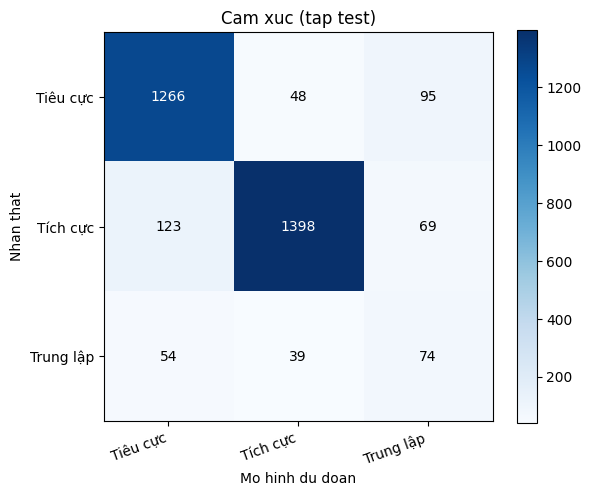

Nhin hang 'Trung lap' de thay lop it mau bi nham sang lop nao nhieu nhat.


In [29]:
from sklearn.metrics import confusion_matrix


def ve_ma_tran(y_that, y_du_doan, ten_nhan, tieu_de):
    cm = confusion_matrix(y_that, y_du_doan, labels=list(range(len(ten_nhan))))
    fig, ax = plt.subplots(figsize=(0.9 * len(ten_nhan) + 3.4, 0.8 * len(ten_nhan) + 3.2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(ten_nhan))); ax.set_xticklabels(ten_nhan, rotation=20, ha="right")
    ax.set_yticks(range(len(ten_nhan))); ax.set_yticklabels(ten_nhan)
    ax.set_xlabel("Mo hinh du doan"); ax.set_ylabel("Nhan that"); ax.set_title(tieu_de)
    for i in range(len(ten_nhan)):
        for j in range(len(ten_nhan)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()
    return cm


ve_ma_tran(y_test, du_doan_test,
           [ten_cx[c] for c in sorted(ten_cx)],
           "Cam xuc (tap test)")
print("Nhin hang 'Trung lap' de thay lop it mau bi nham sang lop nao nhieu nhat.")

### 6.5. Bài toán thứ hai: phân loại chủ đề

Dữ liệu có hai nhãn nên làm được hai bài toán. Bài toán thứ hai là phân loại chủ đề
thành 4 lớp (giảng viên / chương trình / cơ sở vật chất / khác).

Cách làm giống bài toán cảm xúc, chỉ đổi nhãn `y` từ `sentiment` sang `topic`, dùng lại
đúng ma trận đặc trưng đã có, không phải làm lại TF-IDF.

In [30]:
yt_train = df_train["topic"]
yt_val = df_dev["topic"]
yt_test = df_test["topic"]

print("So cau moi lop chu de trong tap train:")
print(yt_train.value_counts().rename(index=ten_cd))

mh_cd = LogisticRegression(max_iter=1000)
mh_cd.fit(X_train, yt_train)

dd_val = mh_cd.predict(X_val)
dd_test = mh_cd.predict(X_test)

print(f"\nDev  -> Accuracy: {accuracy_score(yt_val, dd_val)*100:.2f}%"
      f" | F1 weighted: {f1_score(yt_val, dd_val, average='weighted')*100:.2f}%"
      f" | F1 macro: {f1_score(yt_val, dd_val, average='macro')*100:.2f}%")
print(f"Test -> Accuracy: {accuracy_score(yt_test, dd_test)*100:.2f}%"
      f" | F1 weighted: {f1_score(yt_test, dd_test, average='weighted')*100:.2f}%"
      f" | F1 macro: {f1_score(yt_test, dd_test, average='macro')*100:.2f}%")

print("\nBao cao chi tiet tung lop chu de:")
print(classification_report(yt_test, dd_test,
                            target_names=[ten_cd[c] for c in sorted(ten_cd)],
                            digits=3))

So cau moi lop chu de trong tap train:
topic
Giảng viên        8166
Chương trình      2201
Khác               562
Cơ sở vật chất     497
Name: count, dtype: int64



Dev  -> Accuracy: 86.36% | F1 weighted: 84.83% | F1 macro: 67.81%
Test -> Accuracy: 85.98% | F1 weighted: 84.75% | F1 macro: 69.81%

Bao cao chi tiet tung lop chu de:
                precision    recall  f1-score   support

    Giảng viên      0.891     0.952     0.920      2290
  Chương trình      0.715     0.692     0.703       572
Cơ sở vật chất      0.975     0.807     0.883       145
          Khác      0.659     0.182     0.286       159

      accuracy                          0.860      3166
     macro avg      0.810     0.658     0.698      3166
  weighted avg      0.851     0.860     0.847      3166



#### Ma trận nhầm lẫn: bài toán chủ đề

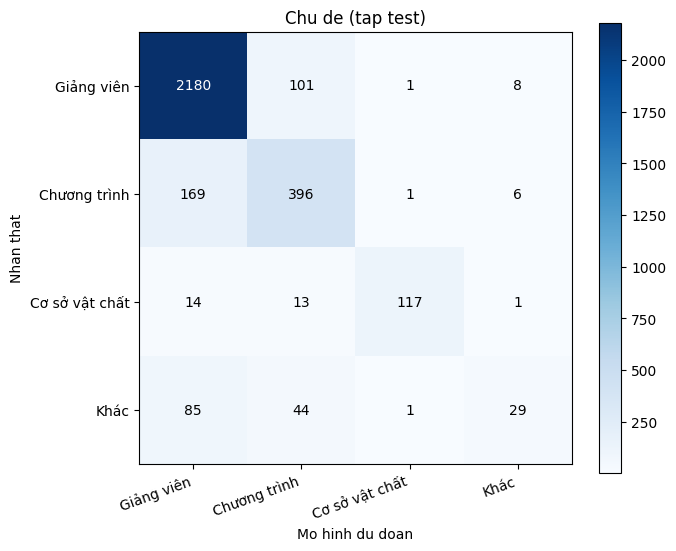

Lop 'Khac' thuong bi nham nhieu nhat - de hieu, vi no khong co chu de ro rang.


In [31]:
ve_ma_tran(yt_test, dd_test,
           [ten_cd[c] for c in sorted(ten_cd)],
           "Chu de (tap test)")
print("Lop 'Khac' thuong bi nham nhieu nhat - de hieu, vi no khong co chu de ro rang.")

## 7. Ứng dụng mô hình: dự đoán cảm xúc cho phản hồi mới

Mục 6 đã huấn luyện mô hình. Mục này biến mô hình đó thành công cụ dùng được: nhập một
câu phản hồi bất kỳ, hệ thống tự phân loại cảm xúc kèm xác suất từng lớp.

Đây là phần thể hiện tính ứng dụng thực tế: khi có phản hồi mới của sinh viên, nhà
trường có thể phân loại tự động thay vì đọc tay từng câu.

Lưu ý: trọng tâm đồ án vẫn là phân tích và trực quan hóa ở các mục trên. Phần dự đoán
này là minh họa khả năng ứng dụng, không nhằm tối ưu độ chính xác.

### 7.1. Hàm dự đoán dùng lại được

In [32]:
def du_doan_cam_xuc(cau):
    """Tra ve cam xuc du doan va xac suat tung lop."""
    cau_sach = lam_sach(cau)
    vector = vec.transform([cau_sach])
    nhan = mh.predict(vector)[0]
    xac_suat = mh.predict_proba(vector)[0]
    ket_qua = {ten_cx[c]: round(p * 100, 1) for c, p in zip(mh.classes_, xac_suat)}
    return ten_cx[nhan], ket_qua


cam_xuc, chi_tiet = du_doan_cam_xuc("thầy giảng rất hay và dễ hiểu")
print("Cảm xúc dự đoán:", cam_xuc)
print("Xác suất từng lớp (%):", chi_tiet)

Cảm xúc dự đoán: Tích cực
Xác suất từng lớp (%): {'Tiêu cực': np.float64(0.1), 'Tích cực': np.float64(99.9), 'Trung lập': np.float64(0.0)}


### 7.2. Thử với nhiều câu phản hồi khác nhau

In [33]:
cac_cau_thu = [
    "thầy giảng rất hay và dễ hiểu",
    "phòng học nóng và thiếu máy chiếu",
    "môn này cũng tạm được không có gì đặc biệt",
    "bài tập quá nhiều và khó hiểu",
    "giáo trình đầy đủ rõ ràng dễ theo dõi",
]

for cau in cac_cau_thu:
    cam_xuc, chi_tiet = du_doan_cam_xuc(cau)
    print(f"[{cam_xuc:9}] {cau}")
    print(f"            -> {chi_tiet}")
    print()

[Tích cực ] thầy giảng rất hay và dễ hiểu
            -> {'Tiêu cực': np.float64(0.1), 'Tích cực': np.float64(99.9), 'Trung lập': np.float64(0.0)}

[Tiêu cực ] phòng học nóng và thiếu máy chiếu
            -> {'Tiêu cực': np.float64(95.3), 'Tích cực': np.float64(0.9), 'Trung lập': np.float64(3.7)}

[Trung lập] môn này cũng tạm được không có gì đặc biệt
            -> {'Tiêu cực': np.float64(11.8), 'Tích cực': np.float64(0.6), 'Trung lập': np.float64(87.6)}

[Tiêu cực ] bài tập quá nhiều và khó hiểu
            -> {'Tiêu cực': np.float64(99.0), 'Tích cực': np.float64(0.9), 'Trung lập': np.float64(0.1)}

[Tích cực ] giáo trình đầy đủ rõ ràng dễ theo dõi
            -> {'Tiêu cực': np.float64(7.6), 'Tích cực': np.float64(75.4), 'Trung lập': np.float64(17.0)}



### 7.3. Tự nhập câu để thử (tùy chọn)

Bỏ dấu `#` ở dòng dưới rồi chạy cell để tự nhập một câu phản hồi và xem kết quả.

In [34]:
# cau_nhap = input("Nhập phản hồi của sinh viên: ")
# cam_xuc, chi_tiet = du_doan_cam_xuc(cau_nhap)
# print("Cảm xúc dự đoán:", cam_xuc)
# print("Xác suất từng lớp (%):", chi_tiet)

## 8. Lập trình hướng đối tượng và đa luồng (Chương 3, Chương 6)

Ba mục nhỏ dưới đây minh họa ba kỹ thuật lập trình Python trên chính dữ liệu của đồ án,
không phải ví dụ rời:

| Mục | Kỹ thuật | Chương |
|---|---|---|
| 8.1 | Đóng gói (encapsulation) | Chương 3 |
| 8.2 | Kế thừa (inheritance) và ghi đè phương thức | Chương 3 |
| 8.3 | Lập trình đa luồng | Chương 6 |

Các lớp được định nghĩa trong `xu_ly.py` và import vào đây, nên notebook lẫn web
(`app.py`) dùng chung một bản code.

### 8.1. Đóng gói: gom dữ liệu và hành vi vào một lớp

Phần trên notebook dùng các hàm rời rạc. Đóng gói nghĩa là gom dữ liệu và những hành vi
xử lý chính dữ liệu đó vào cùng một lớp:

- `XuLyDuLieu`: giữ `self.path`, `self.df` cùng các phương thức `nap()`, `lam_sach()`,
  `thong_ke_cam_xuc()`.
- `MoHinhPhanLoai`: giữ `self.vec`, `self.mo_hinh`, `self.da_train` cùng `huan_luyen()`,
  `du_doan()`.

Nhờ `self`, hai đối tượng tạo từ cùng một lớp vẫn có dữ liệu riêng.

In [35]:
from xu_ly import XuLyDuLieu, MoHinhCamXuc

xu_ly = XuLyDuLieu("data/feedback.csv")
df_oop = xu_ly.nap()                       # gọi phương thức nap()
print("Số phản hồi:", len(df_oop))
print("Thống kê cảm xúc:", xu_ly.thong_ke_cam_xuc())

Số phản hồi: 16175
Thống kê cảm xúc: {'Tích cực': 8038, 'Tiêu cực': 7439, 'Trung lập': 698}


In [36]:
mo_hinh_oop = MoHinhCamXuc()
mo_hinh_oop.huan_luyen(df_oop)

cam_xuc, chi_tiet = mo_hinh_oop.du_doan("thầy giảng rất hay và dễ hiểu", xu_ly)
print("Dự đoán:", cam_xuc)
print("Chi tiết xác suất:", chi_tiet)

Dự đoán: Tích cực
Chi tiết xác suất: {'Tiêu cực': 0.2, 'Tích cực': 99.8, 'Trung lập': 0.1}


### 8.2. Kế thừa: hai bài toán dùng chung một lớp cha

Có hai bài toán là phân loại cảm xúc và phân loại chủ đề. Cách huấn luyện và dự đoán của
hai bài toán giống nhau hoàn toàn, chỉ khác cột nhãn và bộ tên nhãn. Nếu viết hai lớp
riêng thì phần code giống nhau bị lặp hai lần, sửa một chỗ phải nhớ sửa chỗ kia.

Vì vậy `xu_ly.py` tổ chức lại thành:

```
MoHinhPhanLoai              <- lớp cha: giữ toàn bộ phần dùng chung
   ├── MoHinhCamXuc         <- lớp con: ten_nhan = 3 lớp cảm xúc,  cot_nhan = "sentiment"
   └── MoHinhChuDe          <- lớp con: ten_nhan = 4 lớp chủ đề,   cot_nhan = "topic"
```

Hai điểm đáng chú ý ở `MoHinhChuDe`:

- `super().__init__(class_weight=None)`: gọi hàm khởi tạo của lớp cha rồi đổi một tham
  số, không viết lại hàm khởi tạo từ đầu.
- `mo_ta()` được ghi đè (override): gọi `super().mo_ta()` lấy kết quả của lớp cha rồi
  thêm phần riêng vào, thay vì thay thế hoàn toàn.

In [37]:
from xu_ly import MoHinhPhanLoai, MoHinhCamXuc, MoHinhChuDe

print("Quan he ke thua:")
print("  MoHinhCamXuc ke thua MoHinhPhanLoai:",
      issubclass(MoHinhCamXuc, MoHinhPhanLoai))
print("  MoHinhChuDe  ke thua MoHinhPhanLoai:",
      issubclass(MoHinhChuDe, MoHinhPhanLoai))
print("  Thu tu tim phuong thuc cua MoHinhChuDe:",
      [lop.__name__ for lop in MoHinhChuDe.__mro__[:3]])

# cùng một đoạn code chạy được cho CẢ HAI bài toán, đó là lợi của kế thừa
cau_thu = "phòng học nóng và thiếu máy chiếu"
print(f"\nCau thu: \"{cau_thu}\"\n")

for Lop in (MoHinhCamXuc, MoHinhChuDe):
    mo_hinh = Lop().huan_luyen(df_oop)        # huan_luyen() thua tu lop cha
    nhan, chi_tiet = mo_hinh.du_doan(cau_thu, xu_ly)   # du_doan() cung thua tu lop cha
    print(f"{Lop.__name__:14} ({mo_hinh.mo_ta()})")
    print(f"  -> du doan: {nhan}")
    print(f"  -> xac suat: {chi_tiet}\n")

Quan he ke thua:
  MoHinhCamXuc ke thua MoHinhPhanLoai: True
  MoHinhChuDe  ke thua MoHinhPhanLoai: True
  Thu tu tim phuong thuc cua MoHinhChuDe: ['MoHinhChuDe', 'MoHinhPhanLoai', 'object']

Cau thu: "phòng học nóng và thiếu máy chiếu"



MoHinhCamXuc   (phân loại 3 lớp (Tiêu cực, Tích cực, Trung lập))
  -> du doan: Tiêu cực
  -> xac suat: {'Tiêu cực': 92.1, 'Tích cực': 1.8, 'Trung lập': 6.2}



MoHinhChuDe    (chủ đề — phân loại 4 lớp (Giảng viên, Chương trình, Cơ sở vật chất, Khác))
  -> du doan: Cơ sở vật chất
  -> xac suat: {'Giảng viên': 1.5, 'Chương trình': 0.8, 'Cơ sở vật chất': 96.6, 'Khác': 1.1}



### 8.3. Lập trình đa luồng (Chương 6)

Đa luồng là chia việc cho nhiều luồng chạy cùng lúc. Nhóm đo trên hai loại việc khác
nhau của chính đồ án này, vì kết quả của hai loại không giống nhau, và đó mới là điều
quan trọng cần hiểu:

| Loại việc | Ví dụ trong đồ án |
|---|---|
| Nặng CPU (tính toán liên tục) | làm sạch 16.175 câu bằng regex |
| Chờ I/O (chờ đĩa hoặc mạng trả về) | đọc 4 file CSV theo chủ đề ở mục 2.9 |

Hàm dùng ở đây nằm trong `xu_ly.py`, viết bằng `threading.Thread` đúng như Chương 6:
tạo luồng, `start()` cho chạy, `join()` để chờ xong. Hàm `dem_tu_da_luong` còn dùng
`Lock` với `acquire()` và `release()` cho trường hợp nhiều luồng ghi vào cùng một biến.

Về cách chia việc: `lam_sach_da_luong` cắt danh sách thành 4 phần rồi giao mỗi luồng
một phần, chứ không giao từng câu một. Giao từng câu một thì thời gian điều phối còn
lớn hơn thời gian làm việc thật (nhóm đã thử, chậm hơn khoảng 5 lần).

In [38]:
from xu_ly import lam_sach_da_luong, doc_nhieu_file, do_thoi_gian

cac_cau = df["feedback"].tolist()

# ---- Việc 1: nặng CPU, làm sạch 16.175 câu ----
print(f"[Viec nang CPU] Lam sach {len(cac_cau)} cau bang regex")
_, giay_1 = do_thoi_gian(lambda: [xu_ly.lam_sach(c) for c in cac_cau])
print(f"  1 luong : {giay_1:.3f}s")
for so_luong in (2, 4):
    _, giay = do_thoi_gian(lam_sach_da_luong, cac_cau, xu_ly.lam_sach, so_luong)
    print(f"  {so_luong} luong : {giay:.3f}s   (nhanh hon {giay_1/giay:.2f} lan)")

# ---- Việc 2: chờ I/O, đọc 4 file CSV ----
print(f"\n[Viec cho I/O] Doc {len(DUONG_DAN_CHU_DE)} file CSV theo chu de")
_, giay_io_1 = do_thoi_gian(lambda: [pd.read_csv(p) for p in DUONG_DAN_CHU_DE])
print(f"  1 luong : {giay_io_1:.3f}s")
_, giay_io_4 = do_thoi_gian(doc_nhieu_file, DUONG_DAN_CHU_DE, 4)
print(f"  4 luong : {giay_io_4:.3f}s   (nhanh hon {giay_io_1/giay_io_4:.2f} lan)")

print(f"""
Ket luan (so lieu tren may dang chay):
- Viec nang CPU: 4 luong KHONG nhanh hon 1 luong. Nguyen nhan la GIL (Global
  Interpreter Lock) - trong CPython, tai moi thoi diem chi mot luong duoc chay ma
  Python thuc su. Muon nhanh hon cho viec nang CPU thi phai dung da tien trinh
  (multiprocessing), khong phai da luong.
- Viec cho I/O: 4 luong nhanh hon ~{giay_io_1/giay_io_4:.1f} lan. Vi khi mot luong
  dang CHO dia tra du lieu, no nha GIL ra cho luong khac chay - nen thoi gian cho
  cua 4 file bi gop lai thay vi xep hang.

=> Da luong dung cho viec CHO (doc file, goi mang, truy van database), khong phai
   cho viec TINH. Day cung la ly do phan doc du lieu cua he thong duoc viet da luong.
""")

[Viec nang CPU] Lam sach 16175 cau bang regex
  1 luong : 0.163s


  2 luong : 0.159s   (nhanh hon 1.03 lan)
  4 luong : 0.160s   (nhanh hon 1.02 lan)

[Viec cho I/O] Doc 4 file CSV theo chu de


  1 luong : 0.141s
  4 luong : 0.090s   (nhanh hon 1.58 lan)

Ket luan (so lieu tren may dang chay):
- Viec nang CPU: 4 luong KHONG nhanh hon 1 luong. Nguyen nhan la GIL (Global
  Interpreter Lock) - trong CPython, tai moi thoi diem chi mot luong duoc chay ma
  Python thuc su. Muon nhanh hon cho viec nang CPU thi phai dung da tien trinh
  (multiprocessing), khong phai da luong.
- Viec cho I/O: 4 luong nhanh hon ~1.6 lan. Vi khi mot luong
  dang CHO dia tra du lieu, no nha GIL ra cho luong khac chay - nen thoi gian cho
  cua 4 file bi gop lai thay vi xep hang.

=> Da luong dung cho viec CHO (doc file, goi mang, truy van database), khong phai
   cho viec TINH. Day cung la ly do phan doc du lieu cua he thong duoc viet da luong.



#### Đồng bộ hoá bằng `Lock`

Hai hàm trên chia việc sao cho mỗi luồng ghi vào ô riêng, nên không cần khoá. Nhưng khi
các luồng phải cộng dồn vào một biến chung thì khác: hai luồng có thể cùng đọc một giá
trị cũ rồi ghi đè lẫn nhau, làm mất số đếm. Đó là race condition.

Hàm `dem_tu_da_luong` trong `xu_ly.py` là ví dụ: mỗi luồng đếm từ trong phần của mình,
rồi mới `acquire()` khoá để cộng vào dict chung và `release()` nhả ra.

Ô dưới kiểm chứng: đếm bằng nhiều luồng phải cho đúng cùng kết quả với đếm bằng một
luồng. Nếu thiếu khoá, con số sẽ sai và sai khác nhau mỗi lần chạy.

In [ ]:
import collections

from xu_ly import dem_tu_da_luong

cau_sach = df["feedback_sach"].tolist()
chuan = dict(collections.Counter(" ".join(cau_sach).split()))
print("Dem bang 1 luong (Counter):", len(chuan), "tu khac nhau")

for so_luong in (2, 4, 8):
    dem = dem_tu_da_luong(cau_sach, so_luong)
    print(f"  {so_luong} luong -> {len(dem)} tu | khop ket qua 1 luong:", dem == chuan)

print("\nTop 5 tu nhieu nhat:",
      sorted(chuan.items(), key=lambda x: -x[1])[:5])

## 9. Thao tác với cơ sở dữ liệu MySQL (Chương 5)

Phần phân tích trên dùng file CSV (dữ liệu cố định, chỉ đọc). Với phần quản lý người
dùng và lưu phản hồi mới, nhóm dùng MySQL, đúng nội dung Chương 5.

File `database.py` chứa lớp `Database` với các thao tác:
- Tạo bảng `users` (tài khoản) và `phan_hoi` (góp ý) bằng lệnh `CREATE TABLE`.
- Đăng ký và đăng nhập bằng `INSERT`, `SELECT`; mật khẩu được băm trước khi lưu.
- Lưu phản hồi sinh viên: đổi điểm sao (1 đến 5) thành nhãn cảm xúc rồi `INSERT`.

Chuẩn bị trước khi chạy ô dưới: cài MySQL, tạo database và sửa mật khẩu ở `database.py`
cho khớp máy đang chạy.

```sql
CREATE DATABASE lang_nghe_sv;
```

Ô dưới chạy thật khi có MySQL. Nếu máy chưa cài, nó in ra thông báo hướng dẫn chứ không
làm lỗi notebook, nhờ `try / except` (Chương 2).

In [39]:
from database import Database

try:
    db = Database()

    db.dang_ky("sv01", "123456")
    print("Dang nhap dung mat khau :", db.dang_nhap("sv01", "123456"))
    print("Dang nhap sai mat khau  :", db.dang_nhap("sv01", "sai_roi"))

    db.luu_phan_hoi("thay giang rat hay va nhiet tinh", so_sao=5)
    db.luu_phan_hoi("phong hoc nong va thieu may chieu", so_sao=1)

    print("\nPhan hoi dang luu trong MySQL:")
    for ph in db.lay_phan_hoi():
        print("  ", ph)

except Exception as loi:
    print("Chua ket noi duoc MySQL nen bo qua phan nay (notebook van chay tiep).")
    print("Chi tiet loi:", loi)
    print("\nMuon chay that thi: cai MySQL, chay CREATE DATABASE lang_nghe_sv;")
    print("roi sua mat khau trong database.py cho khop may nay.")

Chua ket noi duoc MySQL nen bo qua phan nay (notebook van chay tiep).
Chi tiet loi: 1045 (28000): Access denied for user 'root'@'localhost' (using password: YES)

Muon chay that thi: cai MySQL, chay CREATE DATABASE lang_nghe_sv;
roi sua mat khau trong database.py cho khop may nay.


## 10. Kết luận

### Kết quả mô hình

| Bài toán | Đồ án (đo trên tập test 3.166 câu) |
|---|---|
| Phân loại cảm xúc | 87,10% F1 weighted (mục 6.4) |
| Phân loại chủ đề | 84,75% F1 weighted (mục 6.5) |

Hai con số này đo trên tập test riêng, không dùng để chọn mô hình, nên phản ánh đúng
năng lực thật. Để tham khảo, kết quả từng công bố cho bộ dữ liệu UIT-VSFC là khoảng 88%
(cảm xúc) và trên 84% (chủ đề), tức mô hình của nhóm ở mức tương đương.

### Phát hiện chính từ dữ liệu

Chi tiết ở mục 5. Ba điều đáng chú ý nhất:

1. Cơ sở vật chất: 95,6% phản hồi tiêu cực, điểm yếu rõ nhất, dù chỉ 4,4% sinh viên
   nhắc tới.
2. Chương trình học: 76,6% tiêu cực, tập trung vào việc thiếu giờ thực hành.
3. Giảng viên: 62,1% tích cực, điểm mạnh, được khen "nhiệt tình", "dễ hiểu".

### Quy trình 14 bước, làm ở mục nào

| Bước | Nội dung | Mục |
|---|---|---|
| 1 | Thu thập và hiểu dữ liệu | 0, 1 |
| 2 | Kiểm tra và chuyển đổi kiểu dữ liệu | 2.1 |
| 3 | Xử lý giá trị thiếu | 2.2, 2.3 |
| 4 | Xử lý dữ liệu không hợp lệ | 2.4 |
| 5 | Xử lý dữ liệu trùng lặp | 2.2, 2.3 |
| 6 | Xử lý nhiễu và ngoại lai | 2.7, 2.8 |
| 7 | Chuẩn hóa dữ liệu | 2.5 |
| 8 | Mã hóa dữ liệu phân loại | 2.6 |
| 9 | Xử lý dữ liệu mất cân bằng | 6.3 |
| 10 | Xử lý đặc trưng | 6.2 |
| 11 | Gán nhãn dữ liệu | 2.6 |
| 12 | Chia train / dev / test | 6.1 |
| 13 | Lưu dữ liệu đã xử lý (CSV, JSON, XML) | 2.9 |
| 14 | Phân tích, trực quan hóa, huấn luyện | 3, 4, 6.4, 6.5, 7 |

### Kiến thức từng chương được áp dụng ở đâu

| Chương | Nội dung | Áp dụng trong đồ án |
|---|---|---|
| Ch2 | Python cơ bản, xử lý ngoại lệ | `try/except` ở mục 0 và mục 9 |
| Ch3 | Lập trình hướng đối tượng | Đóng gói (8.1), kế thừa và ghi đè (8.2) |
| Ch4 | Xử lý XML / JSON | Ghi và đọc lại `thong_ke.json`, `thong_ke.xml` (2.9) |
| Ch5 | Thao tác với CSDL | MySQL: đăng nhập, lưu phản hồi (mục 9) |
| Ch6 | Lập trình đa luồng | So sánh việc nặng CPU và việc chờ I/O (8.3) |
| Ch8 | Pandas, Matplotlib | Toàn bộ mục 2, 3, 4 (trọng tâm đồ án) |
| Ch9 | Máy học | Phân loại cảm xúc và chủ đề (mục 6, 7) |

### Hạn chế

Lớp "Trung lập" chỉ chiếm khoảng 4% dữ liệu nên mô hình nhận ra lớp này rất kém (F1 chỉ
0,37) dù accuracy tổng thể 86,5%. Đây là lý do phải xem F1 macro chứ không chỉ xem
accuracy.

Chủ đề trong file người dùng tự upload lên web được đoán bằng từ khóa, không phải bằng
mô hình, nên độ chính xác thấp hơn phần chạy trên dữ liệu UIT-VSFC có nhãn thật.